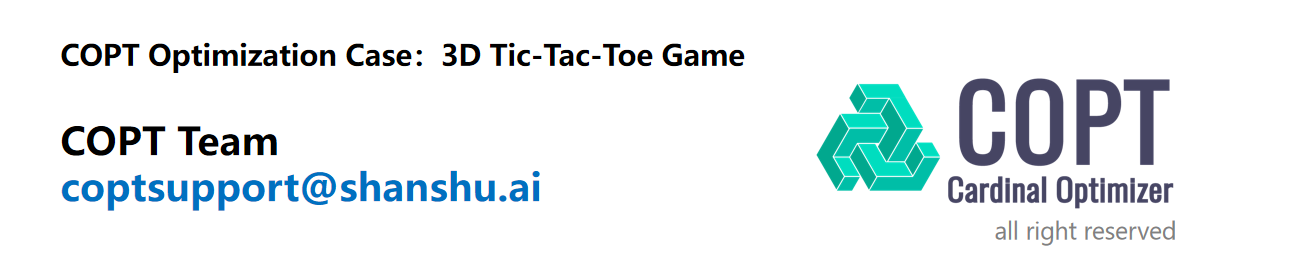

> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


# 3D Tic-Tac-Toe Game Code Implementation
# Steps for Solving the Problem Using COPT Modeling

1. **Import the COPT-Python interface library** `coptpy`

2. Create **Solving Environment** and Solving **Model**

3. Build the model and add the **three elements of the model** in sequence
   - **Decision Variables**
   - **Objective Function**
   - **Constraints**

4. **Solve**

5. View and analyze solution **results**

## COPT Python API solution -- Linear programming problem

COPT is a powerful optimization solver. You only need to describe the problem to COPT (here we use Python to describe the problem), and COPT will help you solve the problem and tell you the optimal solution and related information.

To use COPT to solve optimization problems, you need to first create a COPT environment and create a model in the environment. Then we can add specific problem descriptions to the model, and finally COPT will solve the problem.

### Create COPT environment

First, import the Python API of COPT, which is called coptpy. (Note that if you use coptpy locally, you also need to install the Python interface after installing COPT. For details, see <a href="https://www.shanshu.ai/copt-document/manual?id=19&docType=3" target="_blank">COPT Manual</a>)

In [1]:
from coptpy import *

Next, create the COPT environment. We use the `Envr()` function to create the COPT environment.

In [3]:
# Create COPT environment
env = Envr()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



Create a model called "lp_example" in the COPT environment. Use `createModel()`, which has a parameter `name` to name the model.

In [5]:
# Create COPT model
model = env.createModel("lp_example")

We can view some properties of `model` through `model.status`. Currently, the model has not started to be solved, so it is `COPT.UNSTARTED`.

In [7]:
model.status == COPT.UNSTARTED

True

More possible states of the model are as follows, including:

| State of model solution | Meaning |
| :--- | :--- |
|`COPT.UNSTARTED`|Solution not started|
|`COPT.OPTIMAL`|Solved successfully|
|`COPT.INFEASIBLE`|Model has no solution|
|`COPT.UNBOUNDED`|Optimal value is unbounded|
|`COPT.INF_OR_UNB`|Model has no solution or optimal value is unbounded|
|`COPT.NUMERICAL`|Solving encounters numerical problems|
|`COPT.NODELIMIT`|Solving failed before node limit|
|`COPT.TIMEOUT`|Solving failed before time limit|
|`COPT.UNFINISHED`|Solving terminated. But due to numerical problems, the solver cannot give a result|
|`COPT.INTERRUPTED`|User aborted|

In [9]:
(COPT.UNSTARTED, COPT.OPTIMAL, COPT.INFEASIBLE, \
 COPT.UNBOUNDED, COPT.INF_OR_UNB, COPT.NUMERICAL,\
 COPT.NODELIMIT, COPT.TIMEOUT, COPT.UNFINISHED, COPT.INTERRUPTED)

(0, 1, 2, 3, 4, 5, 6, 8, 9, 10)

### Describe the problem to COPT

#### Add decision variables and range constraints

Use `addVar()` to add decision variables $x, y, z$ in sequence. In this step, we can set the lower and upper bounds of the variables by setting the parameters `lb` and `ub`, respectively, so as to add range constraints to the variables
$$
\begin{aligned}
&0.1\leq x \leq 0.6 \\
&0.2\leq y \leq 1.5 \\
&0.3\leq z \leq 2.8
\end{aligned}
$$
`lb` and `ub` default to `0` and `COPT.INFINITY`, respectively, that is, the variable defaults to $\geq 0$.

Setting the parameter `name` in the model can name the variable (note that this does not refer to the variable name in the Python code, but the variable name in the COPT model).

In [11]:
# Add variables: x, y, z
x = model.addVar(lb=0.1, ub=0.6, name="x")
y = model.addVar(lb=0.2, ub=1.5, name="y")
z = model.addVar(lb=0.3, ub=2.8, name="z")

We look at the `x` variable in Python and see that COPT already knows that it is a decision variable called $x$.

In [13]:
x

<coptpy.Var: x>

#### Add remaining constraints

Use `addConstr()` to add the remaining constraints one by one
$$
\begin{aligned}
&1.5x + 1.2y + 1.8z \leq 2.6 \\
&0.8x + 0.6y + 0.9z \geq 1.2
\end{aligned}
$$

Here, the argument to `addConstr()` is an expression formed by variables. There are two ways to add constraint expressions

|Constraints|coptpy syntax|coptty constants|
|:---:|:---:|:---:|
|$\leq$|`<=`|`COPT.LESS_EQUAL`|
|$\geq$|`>=`|`COPT.GREATER_EQUAL`|
|$=$|`==`|`COPT.EQUAL`|

Add constraints directly using copypy syntax

In [15]:
# Add constraints
model.addConstr(1.5*x + 1.2*y + 1.8*z <= 2.6)
model.addConstr(0.8*x + 0.6*y + 0.9*z >= 1.2)

<coptpy.Constraint: >

or use the copypy constant, which has the same effect as using the copypy syntax above

In [17]:
# Another way to add constraints
# model.addConstr(1.5*x + 1.2*y + 1.8*z, COPT.LESS_EQUAL, 2.6)
# model.addConstr(0.8*x + 0.6*y + 0.9*z, COPT.GREATER_EQUAL, 1.2)

##### Set the objective function

Use `setObjective()` to set the expression of the objective function
$$
\max\ 1.2x + 1.8y + 2.1z
$$
The `sense` parameter determines whether the problem is a maximization problem (`COPT.MAXIMIZE`) or a minimization problem (`COPT.MINIMIZE`).

In [19]:
model.setObjective(1.2*x + 1.8*y + 2.1*z, sense=COPT.MAXIMIZE)

##### Set solver parameters

In fact, we have already described the problem clearly to COPT.

But sometimes, we will set some solver parameters through `setParam()` and make some solving requirements to COPT solver. Here we don't want to wait too long. If COPT solves for more than 10 seconds, COPT will stop automatically.

There are many parameters that can be set in COPT's `COPT.Param`. Here we set the `COPT.Param.TimeLimit` parameter to 10 to meet the requirements.

In [21]:
# Set parameter
model.setParam(COPT.Param.TimeLimit, 10.0)

Setting parameter 'TimeLimit' to 10


### Solving Linear Programming

Everything is ready, only the east wind is missing! Let's solve this linear programming problem. Solving the model is very simple, just use `solve()`.

In [23]:
# Solve the model
model.solve()

Model fingerprint: 23f5362b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    2 rows, 3 columns and 6 non-zero elements
The presolved problem has:
    2 rows, 3 columns and 6 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [6e-01,2e+00]
    Range of rhs coefficients:       [1e+00,3e+00]
    Range of bound coefficients:     [1e-01,3e+00]
    Range of cost coefficients:      [1e+00,2e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    6.2083756300e+00            1           0       0.02s
Dual             1    3.5783473899e+00            0           0       0.02s

Solving finished
Status: Optimal  Objective: 3.5783333333e+00  Iterations: 1  Time:

### View and store solution results

Check the model status and find that the model has been solved.

In [25]:
model.status == COPT.OPTIMAL

True

View the information about the optimal solution and optimal value. `getVars()` can get all variables, `var.name` can get the name of the variable, and `var.x` can get the optimal value of the variable.

In [27]:
# Analyze solution
if model.status == COPT.OPTIMAL:
    print('Objective value: {}'.format(model.objval))
    print('Solving Time: {} seconds'.format(model.SolvingTime))
    
    allvars = model.getVars()
    
    print('Variable solution:')
    for var in allvars:
        print('{0}: {1}'.format(var.name, var.x))
        
    print('Variable basis status:')
    for var in allvars:
        print('{0}: {1}'.format(var.name, var.basis))

Objective value: 3.578333333333334
Solving Time: 0.024000167846679688 seconds
Variable solution:
x: 0.1
y: 1.5
z: 0.3611111111111113
Variable basis status:
x: 0
y: 2
z: 1


We can also use `write()` to save the optimization problem as a .mps file, save the optimal value and optimal solution solved by COPT as a .sol file, save the base solution file of the optimal solution as a .bas file, and save the model parameters as a .par file. COPT will intelligently identify the file format and store the corresponding content. The specific writing method is as follows
```python
# Write model, solution and modified parameters to file
model.write('lp_example.mps')
model.write('lp_example.bas')
model.write('lp_example.sol')
model.write('lp_example.par')
```

Among them, it is worth mentioning that the .mps file format is one of the file formats commonly used in the field of optimization to store optimization problems. After storage, you can use COPT to directly read the .mps format problem next time without the trouble of adding variables or constraints such as `addVar()` and `addConstr()`.

### Summary

We used `Envr()` and `Envr.createModel()` to create the COPT environment and the model in the environment respectively. Then we used `Model.addVar()`, `Model.addConstr()` and `Model.setObjective()` to describe the decision variables, constraints, objective functions and optimization directions of the optimization problem to COPT respectively, and used `Model.setParam()` to limit the optimization time. After solving the model with `Model.solve()`, we used `Model.getVars()` to obtain the decision variables, and by accessing various properties of the model and decision variables, we checked the optimal solution, solution time and optimal value. So far, we have been able to build and solve small-scale linear programming problems on our own!

However, directly using `Model.addVar()` and `Model.addConstr()` can only add single decision variables and constraints in sequence. When we want to **add decision variables and constraints in batches**, they seem a bit troublesome (Python loop statements are required). COPT Python API provides us with more convenient `Model.addVars()` and `Model.addConstrs()`. The following case introduces the use of `Model.addVars()`, and `Model.addConstrs()` can refer to <a href="https://www.shanshu.ai/copt-document/manual?id=19&docType=3" target="_blank">COPT Python API</a>.

On the other hand, in integer programming, **indicator variables** and **indicator constraints** are often encountered. The value of the indicator variable determines whether to select or implement certain options, while the indicator constraint is related to the indicator variable, and is often a constraint that only works when the indicator variable takes a certain value. COPT provides `Model.addGenConstrIndicator()` to add indicator constraints.

In the following three-dimensional tic-tac-toe example (which is an integer programming problem), we will learn how to use these functions to prepare for solving actual complex optimization problems later. 

---

## COPT Python API solution -- 3D Tic-Tac-Toe

We import the COPT Python module and create the environment and model.

In [29]:
from coptpy import *

env = Envr()
model = env.createModel('Tic_Tac_Toe')

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



### Model design

We first create a list of all possible lines on a three-dimensional chessboard. Each line is represented by a three-dimensional Python tuple, and each component of the tuple represents the position coordinates of the relevant grid $(i,j,k)$. There are 49 lines in total.

In [31]:
lines = []
size = 3

for i in range(size):
    for j in range(size):
        for k in range(size):
            if i == 0:
                lines.append(((0,j,k), (1,j,k), (2,j,k)))
            if j == 0:
                lines.append(((i,0,k), (i,1,k), (i,2,k)))
            if k == 0:
                lines.append(((i,j,0), (i,j,1), (i,j,2)))
            if i == 0 and j == 0:
                lines.append(((0,0,k), (1,1,k), (2,2,k)))
            if i == 0 and j == 2:
                lines.append(((0,2,k), (1,1,k), (2,0,k)))
            if i == 0 and k == 0:
                lines.append(((0,j,0), (1,j,1), (2,j,2)))
            if i == 0 and k == 2:
                lines.append(((0,j,2), (1,j,1), (2,j,0)))
            if j == 0 and k == 0:
                lines.append(((i,0,0), (i,1,1), (i,2,2)))
            if j == 0 and k == 2:
                lines.append(((i,0,2), (i,1,1), (i,2,0)))
lines.append(((0,0,0), (1,1,1), (2,2,2)))
lines.append(((2,0,0), (1,1,1), (0,2,2)))
lines.append(((0,2,0), (1,1,1), (2,0,2)))
lines.append(((0,0,2), (1,1,1), (2,2,0)))

len(lines)

49

Next, we create our model and add decision variables. Here, we use `Model.addVars(*indices,lb=0.0,ub=COPT.INFINITY,obj=0.0,vtype=COPT.CONTINUOUS,nameprefix="C")` to batch add $isX$ and $isLine$, where `*indices` is the dimension of the variable, which can also be taken as a list of tuples to generate variables with corresponding subscripts. Note that $isX$ and $isLine$ here are both 0-1 integer variables, and `addVars()` adds `COPT.CONTINUOUS` variables by default, so we need to declare `vtype=COPT.BINARY` here. The following are the variable types in COPT. 
|Variable type|coptpy constant|
|:---|:---:|
|Continuous variable|`COPT.CONTINUOUS` (default)|
|0-1 integer variable|`COPT.BINARY`|
|Integer variable|`COPT.INTEGER`|

`addVars()` will return a tupledict type object encapsulated by COPT. For this type of object, COPT provides convenient functions to operate it.

In [33]:
isX = model.addVars(size, size, size, vtype=COPT.BINARY, nameprefix="isX")
isLine = model.addVars(lines, vtype=COPT.BINARY, nameprefix="isLine")

Now we add constraints. The first constraint states that the board should contain 14 $X$ (and 13 $O$). $$
\begin{equation*}
\sum_{ijk} \text{isX}_{ijk} = 14
\end{equation*}
$$

Where $isX$ is a tupledict object of COPT, COPT provides a convenient `sum()` function to sum it.

If you want to sum all variables of all $isX$, you can use

In [35]:
isX.sum()

0.0 + <coptpy.Var: isX(0,0,0)> + <coptpy.Var: isX(0,0,1)> + <coptpy.Var: isX(0,0,2)> + <coptpy.Var: isX(0,1,0)> + <coptpy.Var: isX(0,1,1)> + <coptpy.Var: isX(0,1,2)> + <coptpy.Var: isX(0,2,0)> + <coptpy.Var: isX(0,2,1)> + <coptpy.Var: isX(0,2,2)> + <coptpy.Var: isX(1,0,0)> + <coptpy.Var: isX(1,0,1)> + <coptpy.Var: isX(1,0,2)> + <coptpy.Var: isX(1,1,0)> + <coptpy.Var: isX(1,1,1)> + <coptpy.Var: isX(1,1,2)> + <coptpy.Var: isX(1,2,0)> + <coptpy.Var: isX(1,2,1)> + <coptpy.Var: isX(1,2,2)> + <coptpy.Var: isX(2,0,0)> + <coptpy.Var: isX(2,0,1)> + <coptpy.Var: isX(2,0,2)> + <coptpy.Var: isX(2,1,0)> + <coptpy.Var: isX(2,1,1)> + <coptpy.Var: isX(2,1,2)> + <coptpy.Var: isX(2,2,0)> + <coptpy.Var: isX(2,2,1)> + <coptpy.Var: isX(2,2,2)> 

Here we can use `isX.sum() == 14` and add the following constraints

In [37]:
x14 = model.addConstr(isX.sum() == 14)

The remaining constraints establish the relationship between $isLine[]$ and $isX[]$. A straight line forms a "line" if and only if its three grid symbols are consistent. In our model, this is related to the three corresponding $isX[]$ variables. When all three symbols are $X$, the sum of $isX[]$ is 3; when all three symbols are $O$, the sum of $isX[]$ is 0. Therefore, we only need to require in the constraint that if $isLine[] = 0$, the sum of the corresponding $isX[]$ must be strictly greater than 0 and less than 3 (that is, greater than or equal to 1 and less than or equal to 2).

$$
\begin{equation*}
\text{isLine}_l == 0 \implies 1 <= isX[l_0] + isX[l_1] + isX[l_2] <= 2 \quad \forall l \in \text{Lines}
\end{equation*}
$$

`Model.addGenConstrIndicator(binvar,binval,lhs,sense=None,rhs=None)` means that when the indicator variable `binvar` is `binval`, the following constraints must be established, otherwise the following constraints can be violated.

In [39]:
for line in lines:
    model.addGenConstrIndicator(isLine[line], False, isX[line[0]] + isX[line[1]] + isX[line[2]] >= 1)
    model.addGenConstrIndicator(isLine[line], False, isX[line[0]] + isX[line[1]] + isX[line[2]] <= 2)

Finally, we set the expression of the objective function and the optimization direction, which is to minimize the number of "wires".

In [41]:
model.setObjective(isLine.sum(), COPT.MINIMIZE)

Now we proceed to the optimization solution.

In [43]:
model.solve()

Model fingerprint: e5d497cc

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    1 rows, 76 columns and 27 non-zero elements
    76 binaries
    98 indicators

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    99 rows, 76 columns and 419 non-zero elements
    76 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+01]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     64.5%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.05s
         0         1  

### Results

The optimal solution only forms 4 "lines". We use `matplotlib` to visualize the results, blue indicates the placement of $X$, and white indicates the placement of $O$ (the third dimension of the chessboard is not shown here).

Objective value: 4.0


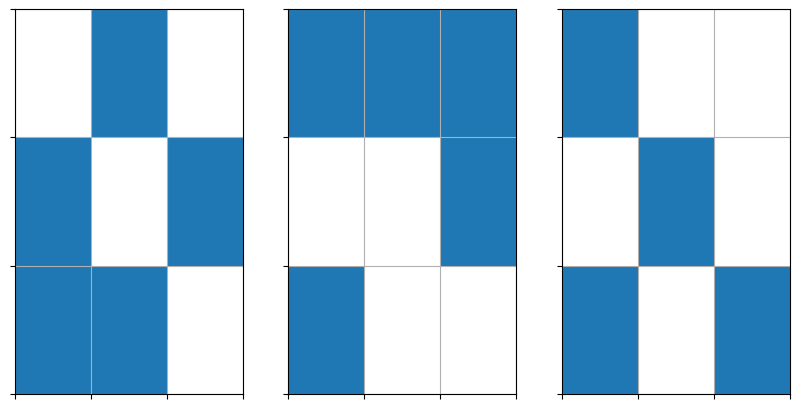

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

if model.status == COPT.OPTIMAL:
    print('Objective value: {}'.format(model.objval))

fig, ax = plt.subplots(1, 3, figsize=(10,5))
for i in range(3):
    ax[i].grid()
    ax[i].set_xticks(range(4))
    ax[i].set_yticks(range(4))
    ax[i].tick_params(labelleft=False, labelbottom=False)
    
for cell in isX.keys():
    if isX[cell].x > 0.5:
        ax[cell[0]].add_patch(plt.Rectangle((cell[1],cell[2]), 1, 1))

plt.show()

---

## Extensions

### Use of `tupledict.sum()`

When solving the three-dimensional tic-tac-toe problem, we used `isX.sum()` to add constraints
$$
\begin{equation*}
\sum_{ijk} \text{isX}_{ijk} = 14
\end{equation*}
$$

If you want to calculate
$$
\sum_{k} isX_{12k}
$$
You can use `'*'` to represent the sum on that dimension

In [47]:
isX.sum(1,2,'*')

0.0 + <coptpy.Var: isX(1,2,0)> + <coptpy.Var: isX(1,2,1)> + <coptpy.Var: isX(1,2,2)> 

If you want to calculate
$$
\sum_{i\in\{1,2\}}\sum_{k}isX_{i1k}
$$
you can use

In [49]:
isX.sum([1,2],1,'*')

0.0 + <coptpy.Var: isX(1,1,0)> + <coptpy.Var: isX(1,1,1)> + <coptpy.Var: isX(1,1,2)> + <coptpy.Var: isX(2,1,0)> + <coptpy.Var: isX(2,1,1)> + <coptpy.Var: isX(2,1,2)> 